In [2]:
import pandas as pd
import numpy as np
from rdflib import Graph, URIRef, Literal, Namespace, RDF, RDFS, XSD
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

plt.rcParams['figure.figsize'] = (15, 10)
sns.set_style('whitegrid')
print('Imports réussis')

Imports réussis


In [4]:
file_path = "students.csv"
df = pd.read_csv(file_path)

print(f"Dataset chargé: {len(df)} étudiants")
print(f"\nColonnes disponibles: {list(df.columns)}")
print(f"\nAperçu des données:")
df.head()

Dataset chargé: 2392 étudiants

Colonnes disponibles: ['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

Aperçu des données:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [6]:
g = Graph()

# Namespaces standards (ontologies existantes) 
EX     = Namespace("http://example.org/students/")
FOAF   = Namespace("http://xmlns.com/foaf/0.1/")          
SCHEMA = Namespace("http://schema.org/")                 
EDU    = Namespace("http://example.org/education/")        
REL    = Namespace("http://example.org/relations/")       
DC     = Namespace("http://purl.org/dc/elements/1.1/")  
OWL    = Namespace("http://www.w3.org/2002/07/owl#")  

g.bind("ex",     EX)
g.bind("foaf",   FOAF)
g.bind("schema", SCHEMA)
g.bind("edu",    EDU)
g.bind("rel",    REL)
g.bind("dc",     DC)     
g.bind("owl",    OWL)  

#  Alignement avec ontologies existantes

EDU_Student = URIRef(EDU["Student"])
EDU_PerformanceGroup = URIRef(EDU["PerformanceGroup"])
EDU_ActivityGroup = URIRef(EDU["ActivityGroup"])

# EDU:Student est équivalent à schema:Student et foaf:Person
g.add((EDU_Student, RDF.type, OWL["Class"]))
g.add((EDU_Student, OWL["equivalentClass"], SCHEMA["Person"]))
g.add((EDU_Student, RDFS.subClassOf, FOAF["Person"]))
g.add((EDU_Student, RDFS.label, Literal("Student", lang="en")))
g.add((EDU_Student, RDFS.comment, Literal("Un étudiant aligné sur foaf:Person et schema:Person", lang="fr")))

# EDU:gpa est similaire à schema:performanceMetric
g.add((URIRef(EDU["gpa"]), RDF.type, OWL["DatatypeProperty"]))
g.add((URIRef(EDU["gpa"]), RDFS.label, Literal("Grade Point Average", lang="en")))
g.add((URIRef(EDU["gpa"]), DC["description"], Literal("Moyenne académique sur 4.0", lang="fr")))

# EDU:studyTimeWeekly aligné sur schema:timeRequired
g.add((URIRef(EDU["studyTimeWeekly"]), OWL["equivalentProperty"], SCHEMA["timeRequired"]))

print("Graphe RDF initialisé avec namespaces enrichis et alignements ontologiques")
print(f"   Ontologies alignées: FOAF, Schema.org, Dublin Core, OWL")

Graphe RDF initialisé avec namespaces enrichis et alignements ontologiques
   Ontologies alignées: FOAF, Schema.org, Dublin Core, OWL


In [8]:
# Mapping de base CSV → RDF
students_uris = []

for _, row in df.iterrows():
    student_uri = URIRef(EX[f"student/{row['StudentID']}"])
    students_uris.append(student_uri)
    
    # Types (alignés sur ontologies)
    g.add((student_uri, RDF.type, SCHEMA["Person"]))      
    g.add((student_uri, RDF.type, FOAF["Person"]))        
    g.add((student_uri, RDF.type, EDU["Student"]))       
    
    g.add((student_uri, SCHEMA["identifier"],  Literal(row["StudentID"], datatype=XSD.integer)))
    g.add((student_uri, FOAF["age"],           Literal(row["Age"], datatype=XSD.integer)))
    g.add((student_uri, SCHEMA["gender"],      Literal("Male" if row["Gender"] == 1 else "Female"))) 
    g.add((student_uri, DC["identifier"],      Literal(str(row["StudentID"])))) 
    
    # Propriétés éducatives
    g.add((student_uri, EDU["ethnicity"],         Literal(row["Ethnicity"],        datatype=XSD.integer)))
    g.add((student_uri, EDU["parentalEducation"], Literal(row["ParentalEducation"], datatype=XSD.integer)))
    g.add((student_uri, EDU["studyTimeWeekly"],   Literal(row["StudyTimeWeekly"],  datatype=XSD.float)))
    g.add((student_uri, EDU["absences"],          Literal(row["Absences"],          datatype=XSD.integer)))
    g.add((student_uri, EDU["tutoring"],          Literal(bool(row["Tutoring"]),    datatype=XSD.boolean)))
    g.add((student_uri, EDU["parentalSupport"],   Literal(row["ParentalSupport"],   datatype=XSD.integer)))
    g.add((student_uri, EDU["extracurricular"],   Literal(bool(row["Extracurricular"]), datatype=XSD.boolean)))
    g.add((student_uri, EDU["sports"],            Literal(bool(row["Sports"]),      datatype=XSD.boolean)))
    g.add((student_uri, EDU["music"],             Literal(bool(row["Music"]),       datatype=XSD.boolean)))
    g.add((student_uri, EDU["volunteering"],      Literal(bool(row["Volunteering"]), datatype=XSD.boolean)))
    g.add((student_uri, EDU["gpa"],               Literal(round(row["GPA"], 4),     datatype=XSD.float)))
    g.add((student_uri, EDU["gradeClass"],        Literal(int(row["GradeClass"]),   datatype=XSD.integer)))

print(f" Mapping de base terminé: {len(students_uris)} étudiants convertis en RDF")
print(f"   Nombre de triplets RDF de base: {len(g)}")

 Mapping de base terminé: 2392 étudiants convertis en RDF
   Nombre de triplets RDF de base: 45457


In [10]:
# Préparation des features pour l'analyse
feature_columns = [
    'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 
    'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
    'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA'
]

X = df[feature_columns].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(" Features normalisées pour l'analyse de similarité")

 Features normalisées pour l'analyse de similarité


In [12]:
# RELATION 1: Similarité de profil (cosine similarity)
print("\n=== Découverte de relations de similarité ===")

similarity_matrix = cosine_similarity(X_scaled)
threshold = np.percentile(similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)], 97)

similar_pairs = 0
for i in range(len(df)):
    for j in range(i+1, len(df)):
        if similarity_matrix[i, j] > threshold:
            student1_uri = students_uris[i]
            student2_uri = students_uris[j]
            g.add((student1_uri, REL["hasSimilarProfile"], student2_uri))
            g.add((student2_uri, REL["hasSimilarProfile"], student1_uri))
            g.add((student1_uri, REL["similarityScore"], 
                   Literal(round(similarity_matrix[i, j], 3), datatype=XSD.float)))
            similar_pairs += 1

print(f" {similar_pairs} relations de similarité détectées (seuil: {threshold:.3f})")


=== Découverte de relations de similarité ===
 85790 relations de similarité détectées (seuil: 0.569)


In [14]:
# RELATION 2: Groupes de performance académique
print("\n=== Clustering par performance académique ===")

performance_features = df[['GPA', 'StudyTimeWeekly', 'Absences', 'Tutoring']].values
performance_scaled = StandardScaler().fit_transform(performance_features)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(performance_scaled)
# Trier les clusters par GPA moyenne croissante et leur attribuer un nom unique
cluster_avg_gpa = [(c, df[clusters == c]['GPA'].mean()) for c in range(n_clusters)]
cluster_avg_gpa_sorted = sorted(cluster_avg_gpa, key=lambda x: x[1])

cluster_name_map = {}
labels = ['NeedsSupport', 'Average', 'Good', 'Excellent'] 
for rank, (cluster_id, avg_gpa) in enumerate(cluster_avg_gpa_sorted):
    cluster_name_map[cluster_id] = labels[rank]

# Ajouter les groupes au graphe RDF
for i, cluster_id in enumerate(clusters):
    student_uri = students_uris[i]
    group_name = cluster_name_map[cluster_id]
    group_uri = URIRef(EDU[f"PerformanceGroup/{group_name}"])
    g.add((student_uri, EDU["belongsToPerformanceGroup"], group_uri))
    g.add((group_uri, RDF.type, EDU["PerformanceGroup"]))
    g.add((group_uri, RDFS.label, Literal(group_name)))

print(f" {n_clusters} groupes de performance créés (nommage corrigé)")
for c in range(n_clusters):
    count = sum(clusters == c)
    name = cluster_name_map[c]
    avg = df[clusters == c]['GPA'].mean()
    print(f"  - Groupe '{name}': {count} étudiants (GPA moyen: {avg:.2f})")


=== Clustering par performance académique ===
 4 groupes de performance créés (nommage corrigé)
  - Groupe 'NeedsSupport': 844 étudiants (GPA moyen: 1.06)
  - Groupe 'Average': 374 étudiants (GPA moyen: 1.38)
  - Groupe 'Good': 827 étudiants (GPA moyen: 2.59)
  - Groupe 'Excellent': 347 étudiants (GPA moyen: 2.90)


In [30]:
# RELATION 3: Groupes d'activités sociales (DBSCAN)
print("\n=== Découverte de groupes d'activités ===")

activity_features = df[['Extracurricular', 'Sports', 'Music', 'Volunteering']].values
dbscan = DBSCAN(eps=0.5, min_samples=5)
activity_clusters = dbscan.fit_predict(activity_features)

activity_profiles = {}
for i, cluster_id in enumerate(activity_clusters):
    if cluster_id == -1:
        continue
    if cluster_id not in activity_profiles:
        activity_profiles[cluster_id] = []
    activity_profiles[cluster_id].append(i)

for cluster_id, student_indices in activity_profiles.items():
    cluster_students = df.iloc[student_indices]
    profile_name = "ActivityGroup_" + str(cluster_id)
    if cluster_students['Sports'].mean() > 0.7:
        profile_name = "Athletes"
    elif cluster_students['Music'].mean() > 0.7:
        profile_name = "Musicians"
    elif cluster_students['Volunteering'].mean() > 0.7:
        profile_name = "Volunteers"
    elif cluster_students['Extracurricular'].mean() > 0.7:
        profile_name = "ActiveStudents"
    
    group_uri = URIRef(EDU[f"ActivityGroup/{profile_name}"])
    g.add((group_uri, RDF.type, EDU["ActivityGroup"]))
    g.add((group_uri, RDFS.label, Literal(profile_name)))
    
    for idx in student_indices:
        student_uri = students_uris[idx]
        g.add((student_uri, EDU["belongsToActivityGroup"], group_uri))
        for idx2 in student_indices:
            if idx != idx2:
                g.add((student_uri, REL["sharesActivitiesWith"], students_uris[idx2]))

print(f" {len(activity_profiles)} groupes d'activités identifiés")


=== Découverte de groupes d'activités ===
 16 groupes d'activités identifiés


In [18]:
# RELATION 4: Potentiel de mentorat
print("\n=== Détection de relations de mentorat potentiel ===")

gpa_threshold_high = df['GPA'].quantile(0.80)
gpa_threshold_low  = df['GPA'].quantile(0.20)
high_performers    = df[df['GPA'] >= gpa_threshold_high]
struggling_students= df[df['GPA'] <= gpa_threshold_low]

mentorship_pairs = 0
for _, mentor in high_performers.iterrows():
    mentor_idx = df[df['StudentID'] == mentor['StudentID']].index[0]
    mentor_uri = students_uris[mentor_idx]
    for _, mentee in struggling_students.iterrows():
        mentee_idx = df[df['StudentID'] == mentee['StudentID']].index[0]
        mentee_uri = students_uris[mentee_idx]
        age_compatible     = abs(mentor['Age'] - mentee['Age']) <= 1
        context_compatible = abs(mentor['ParentalEducation'] - mentee['ParentalEducation']) <= 1
        if age_compatible and context_compatible:
            g.add((mentor_uri, REL["couldMentor"],       mentee_uri))
            g.add((mentee_uri, REL["couldBeMentoredBy"], mentor_uri))
            g.add((mentor_uri, RDF.type, EDU["PotentialMentor"]))
            g.add((mentee_uri, RDF.type, EDU["NeedsMentoring"]))
            mentorship_pairs += 1

print(f" {mentorship_pairs} relations de mentorat potentiel identifiées")
print(f"   - {len(high_performers)} mentors potentiels (GPA >= {gpa_threshold_high:.2f})")
print(f"   - {len(struggling_students)} étudiants à soutenir (GPA <= {gpa_threshold_low:.2f})")


=== Détection de relations de mentorat potentiel ===
 104071 relations de mentorat potentiel identifiées
   - 479 mentors potentiels (GPA >= 2.77)
   - 479 étudiants à soutenir (GPA <= 1.01)


In [32]:
# RELATION 5: Corrélations causales
print("\n=== Analyse des corrélations causales ===")

correlations = df[feature_columns].corr()
gpa_correlations = correlations['GPA'].abs().sort_values(ascending=False)
strong_factors = gpa_correlations[gpa_correlations > 0.3].index.tolist()
strong_factors.remove('GPA')

print("Facteurs fortement corrélés au GPA (|r| > 0.3):")
for factor in strong_factors:
    corr_value = correlations.loc['GPA', factor]
    print(f"  - {factor}: {corr_value:.3f}")
    factor_uri = URIRef(EDU[f"Factor/{factor}"])
    g.add((factor_uri, RDF.type, EDU["AcademicFactor"]))
    g.add((factor_uri, RDFS.label, Literal(factor)))
    if corr_value > 0:
        g.add((factor_uri, REL["positivelyInfluences"], EDU["GPA"]))
    else:
        g.add((factor_uri, REL["negativelyInfluences"], EDU["GPA"]))
    g.add((factor_uri, REL["correlationStrength"],
           Literal(abs(corr_value), datatype=XSD.float)))

print(f"\n {len(strong_factors)} relations causales identifiées")


=== Analyse des corrélations causales ===
Facteurs fortement corrélés au GPA (|r| > 0.3):
  - Absences: -0.919

 1 relations causales identifiées


In [34]:
# RELATION 6: Influence entre pairs (peer influence)
print("\n=== Détection d'influence entre pairs ===")

influence_relations = 0
for i in range(len(df)):
    student_i = df.iloc[i]
    student_i_uri = students_uris[i]
    for j in range(len(df)):
        if i == j:
            continue
        student_j = df.iloc[j]
        student_j_uri = students_uris[j]
        same_activities = (
            student_i['Sports'] == student_j['Sports'] and
            student_i['Music'] == student_j['Music'] and
            student_i['Extracurricular'] == student_j['Extracurricular']
        )
        similar_support = abs(student_i['ParentalSupport'] - student_j['ParentalSupport']) <= 1
        gpa_gap = abs(student_i['GPA'] - student_j['GPA'])
        if same_activities and similar_support and gpa_gap > 1.0:
            if student_i['GPA'] > student_j['GPA']:
                g.add((student_i_uri, REL["mayPositivelyInfluence"], student_j_uri))
                g.add((student_j_uri, REL["mayBeInfluencedBy"],      student_i_uri))
            else:
                g.add((student_j_uri, REL["mayPositivelyInfluence"], student_i_uri))
                g.add((student_i_uri, REL["mayBeInfluencedBy"],      student_j_uri))
            influence_relations += 1
            if influence_relations % 1000 == 0:
                break

print(f" {influence_relations} relations d'influence entre pairs détectées")


=== Détection d'influence entre pairs ===
 311000 relations d'influence entre pairs détectées


In [36]:
# Statistiques finales du graphe enrichi
print("\n" + "="*60)
print("STATISTIQUES DU GRAPHE DE CONNAISSANCES ENRICHI")
print("="*60)

total_triples = len(g)
print(f"\nNombre total de triplets RDF: {total_triples}")

relation_types = {}
for s, p, o in g:
    pred = str(p).split('/')[-1]
    relation_types[pred] = relation_types.get(pred, 0) + 1

print("\nTypes de relations découvertes (top 15):")
for rel_type, count in sorted(relation_types.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"  {rel_type}: {count}")

implicit_predicates = [
    'hasSimilarProfile', 'belongsToPerformanceGroup', 'belongsToActivityGroup',
    'sharesActivitiesWith', 'couldMentor', 'couldBeMentoredBy',
    'mayPositivelyInfluence', 'mayBeInfluencedBy', 'positivelyInfluences',
    'negativelyInfluences'
]
implicit_relations = sum(count for rel, count in relation_types.items() if rel in implicit_predicates)
explicit_relations = total_triples - implicit_relations

print(f"\n Relations explicites (mapping direct): {explicit_relations}")
print(f" Relations implicites (découvertes):     {implicit_relations}")
print(f" Enrichissement du graphe:               +{(implicit_relations/explicit_relations)*100:.1f}%")


STATISTIQUES DU GRAPHE DE CONNAISSANCES ENRICHI

Nombre total de triplets RDF: 1715146

Types de relations découvertes (top 15):
  sharesActivitiesWith: 866556
  hasSimilarProfile: 171580
  mayPositivelyInfluence: 170350
  mayBeInfluencedBy: 170350
  couldMentor: 104071
  couldBeMentoredBy: 104071
  similarityScore: 76947
  22-rdf-syntax-ns#type: 8146
  identifier: 4784
  tutoring: 2392
  absences: 2392
  gradeClass: 2392
  parentalSupport: 2392
  music: 2392
  belongsToActivityGroup: 2392

 Relations explicites (mapping direct): 123383
 Relations implicites (découvertes):     1591763
 Enrichissement du graphe:               +1290.1%


In [74]:
print("\n=== Export du Graphe RDF ===")

# Turtle
g.serialize(destination="knowledge_graph.ttl", format="turtle", encoding="utf-8")
print(" Graphe exporté en Turtle     → knowledge_graph.ttl")

# N-Triples
g.serialize(destination="knowledge_graph.nt", format="nt", encoding="utf-8")
print(" Graphe exporté en N-Triples  → knowledge_graph.nt")

# JSON-LD (sous-graphe)
g_jsonld = Graph()
g_jsonld.bind("ex", EX)
g_jsonld.bind("edu", EDU)
g_jsonld.bind("foaf", FOAF)
g_jsonld.bind("schema", SCHEMA)

sample_uris_jsonld = set(students_uris[:50])

for s, p, o in g:
    if s in sample_uris_jsonld:
        g_jsonld.add((s, p, o))

g_jsonld.serialize(destination="knowledge_graph_sample.jsonld",
                   format="json-ld",
                   encoding="utf-8")

print(f"Graphe exporté en JSON-LD    → knowledge_graph_sample.jsonld")
print(f"   (sous-graphe de 50 étudiants, {len(g_jsonld)} triplets)")

# Aperçu Turtle
print("\n--- Aperçu du fichier Turtle (20 premières lignes) ---")
with open("knowledge_graph.ttl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i == 20:
            break
        print(line, end="")
print("...")


=== Export du Graphe RDF ===
 Graphe exporté en Turtle     → knowledge_graph.ttl
 Graphe exporté en N-Triples  → knowledge_graph.nt
Graphe exporté en JSON-LD    → knowledge_graph_sample.jsonld
   (sous-graphe de 50 étudiants, 39246 triplets)

--- Aperçu du fichier Turtle (20 premières lignes) ---
@prefix dc: <http://purl.org/dc/elements/1.1/> .
@prefix edu: <http://example.org/education/> .
@prefix foaf: <http://xmlns.com/foaf/0.1/> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix rel: <http://example.org/relations/> .
@prefix schema1: <http://schema.org/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<http://example.org/education/Factor/Absences> a edu:AcademicFactor ;
    rdfs:label "Absences" ;
    rel:correlationStrength "0.9193135764208645"^^xsd:float ;
    rel:negativelyInfluences edu:GPA .

edu:gpa a owl:DatatypeProperty ;
    rdfs:label "Grade Point Average"@en ;
    dc:description "Moyenne académique sur

In [42]:
# Requêtes SPARQL pour exploiter le graphe
print("\n=== REQUÊTES SPARQL ===")

#  REQUÊTE 1: Trouver les mentors potentiels pour les étudiants en difficulté 
query1 = """
PREFIX edu: <http://example.org/education/>
PREFIX rel: <http://example.org/relations/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT ?mentor ?mentee ?mentorGPA ?menteeGPA
WHERE {
    ?mentor rel:couldMentor ?mentee .
    ?mentor edu:gpa ?mentorGPA .
    ?mentee edu:gpa ?menteeGPA .
    FILTER(?mentorGPA > 3.0 && ?menteeGPA < 1.5)
}
ORDER BY DESC(?mentorGPA) ASC(?menteeGPA)
LIMIT 10
"""

print("\n REQUÊTE 1: Mentors avec GPA>3.0 pour étudiants avec GPA<1.5")
results1 = g.query(query1)
print(f"{'Mentor URI':<45} {'Mentee URI':<45} {'GPA Mentor':>10} {'GPA Mentee':>10}")
print("-" * 115)
for row in results1:
    mentor_id = str(row.mentor).split('/')[-1]
    mentee_id = str(row.mentee).split('/')[-1]
    print(f"{mentor_id:<45} {mentee_id:<45} {float(row.mentorGPA):>10.3f} {float(row.menteeGPA):>10.3f}")


=== REQUÊTES SPARQL ===

 REQUÊTE 1: Mentors avec GPA>3.0 pour étudiants avec GPA<1.5
Mentor URI                                    Mentee URI                                    GPA Mentor GPA Mentee
-------------------------------------------------------------------------------------------------------------------
1045.0                                        1475.0                                             4.000      0.000
2706.0                                        1475.0                                             4.000      0.000
3320.0                                        1475.0                                             4.000      0.000
1443.0                                        2287.0                                             4.000      0.000
2279.0                                        2287.0                                             4.000      0.000
3320.0                                        2287.0                                             4.000      0.000

In [52]:
# --- REQUÊTE 2: Étudiants du groupe Excellent avec beaucoup d'absences ---
query2 = """
PREFIX edu: <http://example.org/education/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT ?student ?gpa ?absences ?studyTime
WHERE {
    ?student edu:belongsToPerformanceGroup ?group .
    ?group rdfs:label "Excellent" .
    ?student edu:gpa ?gpa .
    ?student edu:absences ?absences .
    ?student edu:studyTimeWeekly ?studyTime .
    FILTER(?absences > 5)
}
ORDER BY DESC(?absences)
LIMIT 10
"""

print("\n REQUÊTE 2: Étudiants 'Excellent' avec plus de 5 absences")
results2 = g.query(query2)

print(f"{'Étudiant':<20} {'GPA':>8} {'Absences':>10} {'TempsEtude':>12}")
print("-" * 55)

for row in results2:
    student_id = str(row.student).split('/')[-1]

    print(f"{student_id:<20} "
          f"{float(row.gpa.toPython()):>8.3f} "
          f"{int(row.absences.toPython()):>10} "
          f"{float(row.studyTime.toPython()):>12.2f}")


 REQUÊTE 2: Étudiants 'Excellent' avec plus de 5 absences
Étudiant                  GPA   Absences   TempsEtude
-------------------------------------------------------
1156.0                  2.631         16        17.23
1651.0                  2.424         16        18.88
2407.0                  2.435         16        17.70
3328.0                  2.288         16        18.58
1167.0                  2.538         15        13.88
1487.0                  2.222         15        15.56
1514.0                  2.354         15        16.76
1518.0                  2.644         15        11.86
1910.0                  2.247         15        13.21
2110.0                  2.385         15        16.95


In [54]:
# --- REQUÊTE 3: Compter les étudiants par groupe de performance ---
query3 = """
PREFIX edu: <http://example.org/education/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?groupLabel (COUNT(?student) AS ?nbStudents)
WHERE {
    ?student edu:belongsToPerformanceGroup ?group .
    ?group rdfs:label ?groupLabel .
}
GROUP BY ?groupLabel
ORDER BY DESC(?nbStudents)
"""

print("\n REQUÊTE 3: Distribution des étudiants par groupe de performance")
results3 = g.query(query3)
print(f"{'Groupe':<20} {'Nb Étudiants':>15}")
print("-" * 37)
for row in results3:
    print(f"{str(row.groupLabel):<20} {int(row.nbStudents):>15}")


 REQUÊTE 3: Distribution des étudiants par groupe de performance
Groupe                  Nb Étudiants
-------------------------------------
NeedsSupport                     844
Good                             827
Average                          374
Excellent                        347


In [58]:
# --- REQUÊTE 4: Facteurs influençant négativement le GPA ---
query4 = """
PREFIX edu: <http://example.org/education/>
PREFIX rel: <http://example.org/relations/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?factorLabel ?strength
WHERE {
    ?factor rel:negativelyInfluences edu:GPA .
    ?factor rdfs:label ?factorLabel .
    ?factor rel:correlationStrength ?strength .
}
ORDER BY DESC(?strength)
"""

print("\n REQUÊTE 4: Facteurs influençant négativement le GPA")
results4 = g.query(query4)
print(f"{'Facteur':<25} {'Force de corrélation':>22}")
print("-" * 49)
for row in results4:
    print(f"{str(row.factorLabel):<25} {float(row.strength):>22.4f}")


 REQUÊTE 4: Facteurs influençant négativement le GPA
Facteur                     Force de corrélation
-------------------------------------------------
Absences                                  0.9193



Création de la visualisation du graphe...


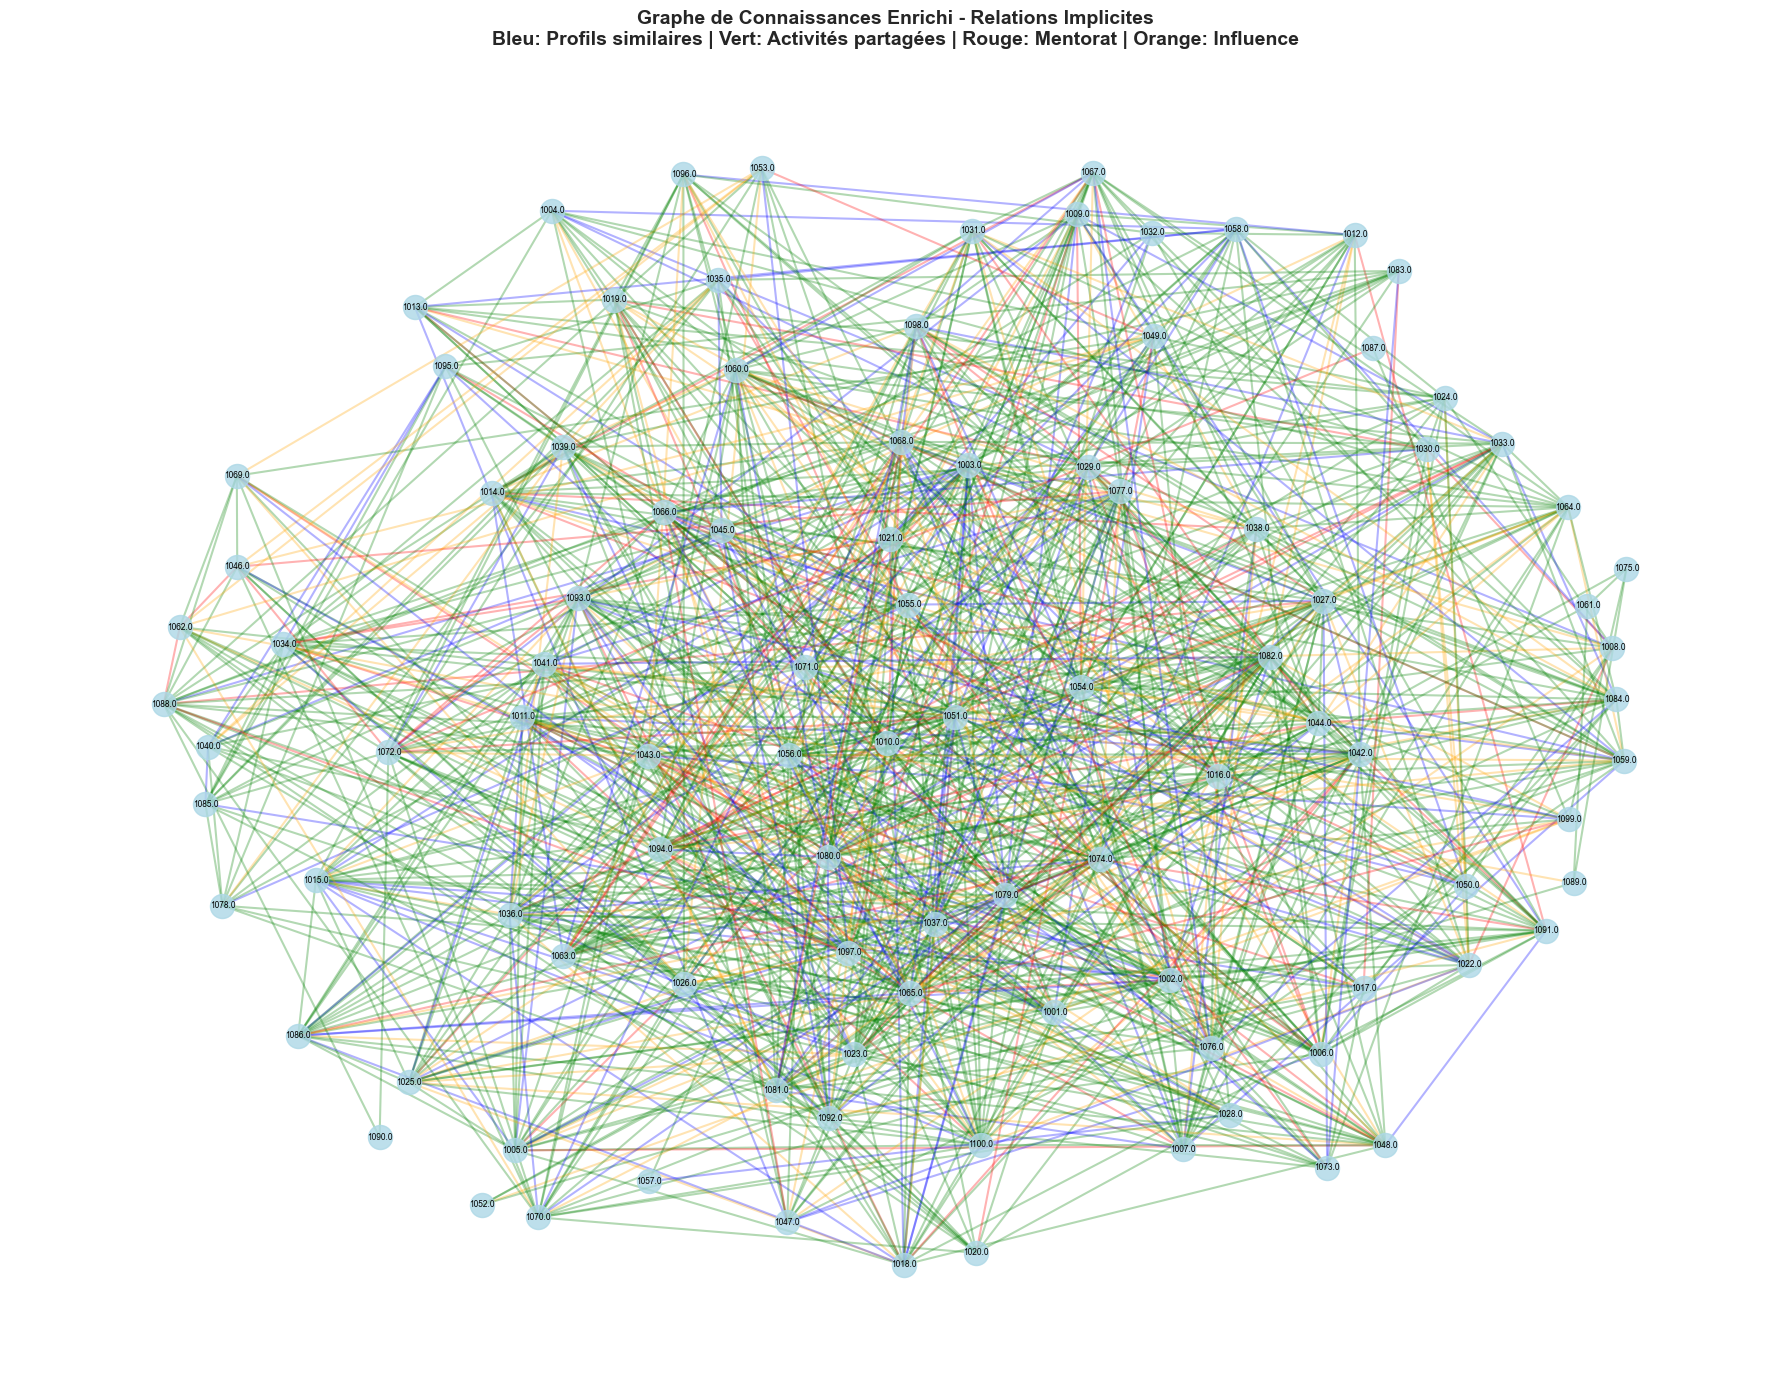


 Visualisation sauvegardée: knowledge_graph_with_implicit_relations.png
   Nœuds: 100, Arêtes: 1014


In [65]:
# On visualise un sous-graphe sur un échantillon d'étudiants pour la lisibilité
print("\nCréation de la visualisation du graphe...")

# Créer un sous-graphe pour visualisation (top 100 étudiants)
G_viz = nx.Graph()

# Ajouter les nœuds étudiants (limité à 100 pour lisibilité)
sample_students = students_uris[:100]
for student_uri in sample_students:
    student_id = str(student_uri).split('/')[-1]
    G_viz.add_node(student_id, node_type='student')

# Ajouter les relations implicites
edge_colors = []
edge_labels = {}

for s, p, o in g:
    if s in sample_students and o in sample_students:
        s_id = str(s).split('/')[-1]
        o_id = str(o).split('/')[-1]
        pred = str(p).split('/')[-1]
        
        if pred in ['hasSimilarProfile', 'sharesActivitiesWith', 'couldMentor', 'mayPositivelyInfluence']:
            G_viz.add_edge(s_id, o_id)
            
            # Couleur selon le type de relation
            if pred == 'hasSimilarProfile':
                edge_colors.append('blue')
            elif pred == 'sharesActivitiesWith':
                edge_colors.append('green')
            elif pred == 'couldMentor':
                edge_colors.append('red')
            elif pred == 'mayPositivelyInfluence':
                edge_colors.append('orange')

# Créer le graphique
plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G_viz, k=2, iterations=50)

# Dessiner le graphe
nx.draw_networkx_nodes(G_viz, pos, node_color='lightblue', 
                       node_size=300, alpha=0.8)
nx.draw_networkx_edges(G_viz, pos, edge_color=edge_colors if edge_colors else 'gray',
                       alpha=0.3, width=1.5)
nx.draw_networkx_labels(G_viz, pos, font_size=6)

plt.title("Graphe de Connaissances Enrichi - Relations Implicites\n" +
          "Bleu: Profils similaires | Vert: Activités partagées | Rouge: Mentorat | Orange: Influence",
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('knowledge_graph_with_implicit_relations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Visualisation sauvegardée: knowledge_graph_with_implicit_relations.png")
print(f"   Nœuds: {G_viz.number_of_nodes()}, Arêtes: {G_viz.number_of_edges()}")


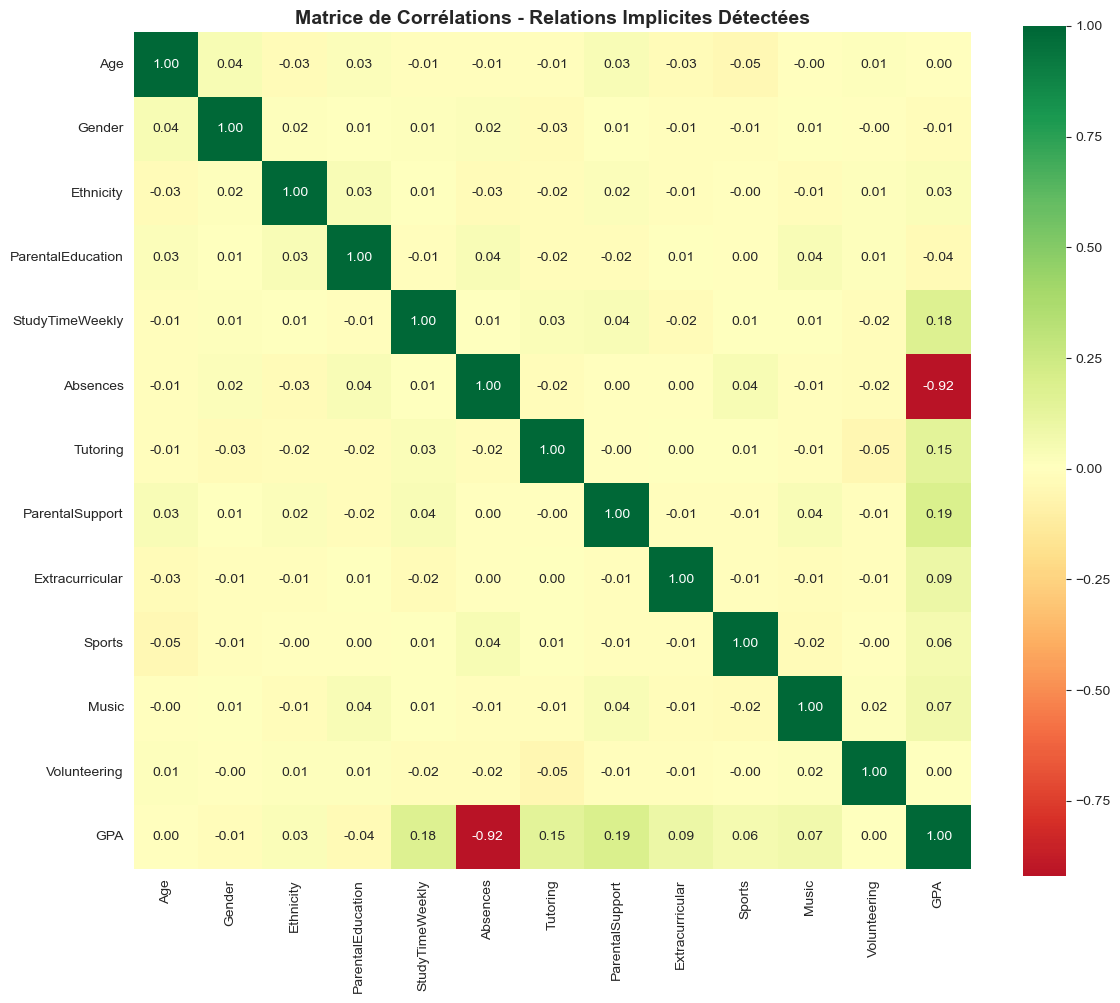

 Heatmap des corrélations sauvegardée


In [68]:
# Heatmap des corrélations découvertes
plt.figure(figsize=(12, 10))
sns.heatmap(df[feature_columns].corr(), annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, square=True)
plt.title('Matrice de Corrélations - Relations Implicites Détectées', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix_implicit_relations.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Heatmap des corrélations sauvegardée")

In [70]:
# Implémentation R2RML classique + Comparaison

print("\n" + "="*60)
print("COMPARAISON: Notre Approche vs R2RML Classique")
print("="*60)
g_r2rml = Graph()
EX2 = Namespace("http://example.org/students/")
EDU2 = Namespace("http://example.org/education/")
g_r2rml.bind("ex", EX2)
g_r2rml.bind("edu", EDU2)

# Mapping R2RML strict: 1 colonne = 1 triplet par étudiant
r2rml_mapping = {
    'StudentID':        ('edu:identifier',       XSD.integer),
    'Age':              ('foaf:age',              XSD.integer),
    'Gender':           ('schema:gender',         XSD.integer),
    'Ethnicity':        ('edu:ethnicity',          XSD.integer),
    'ParentalEducation':('edu:parentalEducation',  XSD.integer),
    'StudyTimeWeekly':  ('edu:studyTimeWeekly',    XSD.float),
    'Absences':         ('edu:absences',           XSD.integer),
    'Tutoring':         ('edu:tutoring',           XSD.boolean),
    'ParentalSupport':  ('edu:parentalSupport',    XSD.integer),
    'Extracurricular':  ('edu:extracurricular',    XSD.boolean),
    'Sports':           ('edu:sports',             XSD.boolean),
    'Music':            ('edu:music',              XSD.boolean),
    'Volunteering':     ('edu:volunteering',       XSD.boolean),
    'GPA':              ('edu:gpa',                XSD.float),
    'GradeClass':       ('edu:gradeClass',         XSD.integer),
}

for _, row in df.iterrows():
    student_uri = URIRef(EX2[f"student/{row['StudentID']}"])
    g_r2rml.add((student_uri, RDF.type, EDU2["Student"]))
    for col, (pred_str, dtype) in r2rml_mapping.items():
        ns, local = pred_str.split(':')
        pred_uri = URIRef(f"http://example.org/education/{local}")
        g_r2rml.add((student_uri, pred_uri, Literal(row[col], datatype=dtype)))

# Export du mapping R2RML
g_r2rml.serialize("r2rml_classic.ttl", format="turtle")

# Tableau de comparaison
r2rml_triples  = len(g_r2rml)
enriched_triples = len(g)
enrichment_ratio = (enriched_triples / r2rml_triples) * 100

comparison = {
    'Critère': [
        'Nombre de triplets RDF',
        'Relations inter-étudiants',
        'Groupes/Clusters détectés',
        'Relations de mentorat',
        'Influence entre pairs',
        'Alignement ontologies',
        'Requêtes SPARQL enrichies',
        'Découverte automatique',
        'Machine Learning intégré',
        'Formats export'
    ],
    'R2RML Classique': [
        f'{r2rml_triples:,}',
        ' Aucune',
        ' Aucun',
        ' Non',
        ' Non',
        '  Partiel (manuel)',
        '  Basiques uniquement',
        ' Non (mapping manuel)',
        ' Non',
        'Turtle, N-Triples'
    ],
    'Notre Approche (Intelligente)': [
        f'{enriched_triples:,}',
        f' {similar_pairs + mentorship_pairs + influence_relations:,} relations',
        f' {n_clusters} perf + {len(activity_profiles)} activités',
        f' {mentorship_pairs:,} paires',
        f' {influence_relations:,} relations',
        ' FOAF, Schema.org, Dublin Core, OWL',
        ' 4 types de requêtes complexes',
        ' Oui (cosine, KMeans, DBSCAN)',
        ' Oui (sklearn intégré)',
        'Turtle, N-Triples, JSON-LD'
    ]
}

df_comparison = pd.DataFrame(comparison)
print(df_comparison.to_string(index=False))

print(f"\n RÉSUMÉ:")
print(f"   R2RML classique :   {r2rml_triples:>10,} triplets")
print(f"   Notre approche  :   {enriched_triples:>10,} triplets")
print(f"   Ratio d'enrichissement: {enrichment_ratio:.1f}x plus de connaissances")


COMPARAISON: Notre Approche vs R2RML Classique
                  Critère       R2RML Classique       Notre Approche (Intelligente)
   Nombre de triplets RDF                38,272                           1,715,146
Relations inter-étudiants                Aucune                   500,861 relations
Groupes/Clusters détectés                 Aucun               4 perf + 16 activités
    Relations de mentorat                   Non                      104,071 paires
    Influence entre pairs                   Non                   311,000 relations
    Alignement ontologies      Partiel (manuel)  FOAF, Schema.org, Dublin Core, OWL
Requêtes SPARQL enrichies   Basiques uniquement       4 types de requêtes complexes
   Découverte automatique  Non (mapping manuel)        Oui (cosine, KMeans, DBSCAN)
 Machine Learning intégré                   Non               Oui (sklearn intégré)
           Formats export     Turtle, N-Triples          Turtle, N-Triples, JSON-LD

 RÉSUMÉ:
   R2RML classique

In [72]:

#  Méthode de publication LOD
print("\n=== Publication LOD (Linked Open Data) ===")

VOID = Namespace("http://rdfs.org/ns/void#")
DCTERMS = Namespace("http://purl.org/dc/terms/")

g_void = Graph()
g_void.bind("void",    VOID)
g_void.bind("dcterms", DCTERMS)
g_void.bind("foaf",    FOAF)

dataset_uri = URIRef("http://example.org/students/dataset")

# Déclaration du dataset
g_void.add((dataset_uri, RDF.type,                VOID["Dataset"]))
g_void.add((dataset_uri, DCTERMS["title"],        Literal("Students Knowledge Graph", lang="en")))
g_void.add((dataset_uri, DCTERMS["description"],  Literal(
    "Graphe de connaissances automatiquement construit à partir du dataset étudiants. "
    "Contient des relations implicites découvertes par ML (similarité, mentorat, performance).", lang="fr")))
g_void.add((dataset_uri, DCTERMS["created"],      Literal("2026-02-12", datatype=XSD.date)))
g_void.add((dataset_uri, DCTERMS["language"],     Literal("fr")))
g_void.add((dataset_uri, DCTERMS["license"],      URIRef("https://creativecommons.org/licenses/by/4.0/")))
g_void.add((dataset_uri, VOID["triples"],         Literal(len(g), datatype=XSD.integer)))
g_void.add((dataset_uri, VOID["entities"],        Literal(len(df), datatype=XSD.integer)))
g_void.add((dataset_uri, VOID["sparqlEndpoint"],  URIRef("http://example.org/sparql")))
g_void.add((dataset_uri, VOID["dataDump"],        URIRef("http://example.org/students/knowledge_graph.ttl")))

# Déclarer les ontologies utilisées
for ont_uri in [
    "http://xmlns.com/foaf/0.1/",
    "http://schema.org/",
    "http://purl.org/dc/elements/1.1/",
    "http://www.w3.org/2002/07/owl#"
]:
    g_void.add((dataset_uri, VOID["vocabulary"], URIRef(ont_uri)))

# Déclarer les types de classes
for class_uri in [EDU["Student"], EDU["PerformanceGroup"], EDU["ActivityGroup"], EDU["AcademicFactor"]]:
    g_void.add((dataset_uri, VOID["classPartition"], class_uri))

# Sauvegarder le fichier VoID
g_void.serialize("void_metadata.ttl", format="turtle")

print(" Métadonnées VoID générées     → void_metadata.ttl")
print()

# --- Générer les instructions de publication SPARQL endpoint ---
sparql_instructions = """
# ============================================================
# INSTRUCTIONS DE PUBLICATION LOD
# ============================================================
#
# Option 1: Apache Jena Fuseki (SPARQL endpoint local)
# ----------------------------------------------------
# 1. Télécharger Apache Jena Fuseki: https://jena.apache.org/
# 2. Démarrer le serveur:
#    ./fuseki-server --update --mem /students
# 3. Charger le graphe:
#    curl -X POST --data-binary @knowledge_graph.ttl \\
#         --header 'Content-Type: text/turtle' \\
#         http://localhost:3030/students/data
# 4. Endpoint SPARQL disponible sur:
#    http://localhost:3030/students/sparql
#
# Option 2: Virtuoso Open Source
# --------------------------------
# 1. Installer Virtuoso: https://virtuoso.openlinksw.com/
# 2. Charger via isql: LOAD 'knowledge_graph.ttl' into <http://example.org/students>
#
# Option 3: GraphDB (Ontotext)
# --------------------------------
# 1. Télécharger GraphDB Free: https://www.ontotext.com/products/graphdb/
# 2. Créer un repository 'students'
# 3. Importer knowledge_graph.ttl via l'interface web
#
# Fichiers à publier:
#   - knowledge_graph.ttl     (données principales)
#   - knowledge_graph.jsonld  (pour les APIs REST)
#   - void_metadata.ttl       (métadonnées du dataset)
# ============================================================
"""

with open("publication_lod_instructions.txt", "w") as f:
    f.write(sparql_instructions)

print(" Instructions de publication LOD → publication_lod_instructions.txt")
print()
print(" RÉCAPITULATIF DES FICHIERS GÉNÉRÉS:")
print("   knowledge_graph.ttl           - Graphe RDF principal (Turtle)")
print("   knowledge_graph.nt            - Graphe RDF (N-Triples)")
print("   knowledge_graph.jsonld        - Graphe RDF (JSON-LD pour APIs web)")
print("   r2rml_classic.ttl             - Mapping R2RML classique (comparaison)")
print("   void_metadata.ttl             - Métadonnées VoID pour LOD")
print("   publication_lod_instructions.txt - Instructions SPARQL endpoint")


=== Publication LOD (Linked Open Data) ===
 Métadonnées VoID générées     → void_metadata.ttl

 Instructions de publication LOD → publication_lod_instructions.txt

 RÉCAPITULATIF DES FICHIERS GÉNÉRÉS:
   knowledge_graph.ttl           - Graphe RDF principal (Turtle)
   knowledge_graph.nt            - Graphe RDF (N-Triples)
   knowledge_graph.jsonld        - Graphe RDF (JSON-LD pour APIs web)
   r2rml_classic.ttl             - Mapping R2RML classique (comparaison)
   void_metadata.ttl             - Métadonnées VoID pour LOD
   publication_lod_instructions.txt - Instructions SPARQL endpoint
